# Data Quality Profiling & Scorecard

**Author:** Aman Bohra · Senior Analytics & BI Professional
**Portfolio:** https://amandbohra.github.io/portfolio/

Before any dashboard is trustworthy, the data underneath has to be. This notebook profiles a
deliberately **messy synthetic dataset** — missing values, duplicates, out-of-range numbers,
inconsistent categories, invalid dates — and produces a **data-quality scorecard**, mirroring the
maker/checker governance I've used to improve accuracy ~35% and cut audit findings ~15%.

> ⚠️ Synthetic data for demonstration only — no real or confidential client data.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25})
rng = np.random.default_rng(3)


## 1. Create a messy dataset (policies)

In [2]:
N = 1500
df = pd.DataFrame({
    "policy_id": [f"P{100000+i}" for i in range(N)],
    "region": rng.choice(["North","South","East","West","north ","WEST"], N, p=[.28,.24,.2,.2,.05,.03]),
    "premium": rng.normal(1200, 300, N).round(0),
    "age": rng.integers(18, 80, N).astype(float),
    "start_date": pd.to_datetime("2023-01-01") + pd.to_timedelta(rng.integers(0, 800, N), unit="D"),
})
# inject quality issues
df.loc[rng.choice(N, 90, replace=False), "premium"] = np.nan            # missing
df.loc[rng.choice(N, 40, replace=False), "age"] = rng.choice([-5,0,150,999], 40)  # out of range
df.loc[rng.choice(N, 25, replace=False), "region"] = None              # missing category
dups = df.sample(30, random_state=1)                                   # duplicate rows
df = pd.concat([df, dups], ignore_index=True)
df.loc[rng.choice(len(df), 20, replace=False), "start_date"] = pd.NaT  # missing dates
print("rows:", len(df))
df.head()


rows: 1530


,policy_id,region,premium,age,start_date
0,P100000,North,865.0,33.0,2023-07-14
1,P100001,North,1333.0,55.0,2024-07-15
2,P100002,West,1129.0,53.0,2024-07-07
3,P100003,East,631.0,63.0,2025-01-19
4,P100004,North,683.0,51.0,2024-03-30


## 2. Profile: completeness, uniqueness, validity, consistency

In [3]:
report = {}

# completeness (per column)
completeness = 1 - df.isna().mean()

# uniqueness
dup_rows = df.duplicated().sum()
dup_ids = df["policy_id"].duplicated().sum()

# validity
age_valid = df["age"].between(18, 100).mean()
premium_valid = df["premium"].between(100, 5000).mean()
date_valid = df["start_date"].notna().mean()

# consistency: region should be one of a clean set (case/space-insensitive)
clean_regions = {"north","south","east","west"}
region_norm = df["region"].astype(str).str.strip().str.lower()
region_consistent = region_norm.isin(clean_regions).mean()

print("Completeness by column:\n", (completeness*100).round(1).to_string(), "\n")
print(f"Duplicate rows: {dup_rows}   Duplicate policy_ids: {dup_ids}")
print(f"Age in [18,100]: {age_valid:.1%}   Premium in [100,5000]: {premium_valid:.1%}")
print(f"Valid start_date: {date_valid:.1%}   Region consistent: {region_consistent:.1%}")


Completeness by column:
 policy_id     100.0
region         98.4
premium        94.1
age           100.0
start_date     98.7 

Duplicate rows: 30   Duplicate policy_ids: 30
Age in [18,100]: 97.4%   Premium in [100,5000]: 94.1%
Valid start_date: 98.7%   Region consistent: 98.4%


## 3. Data-quality scorecard
Roll the checks into per-dimension pass rates and an overall score.

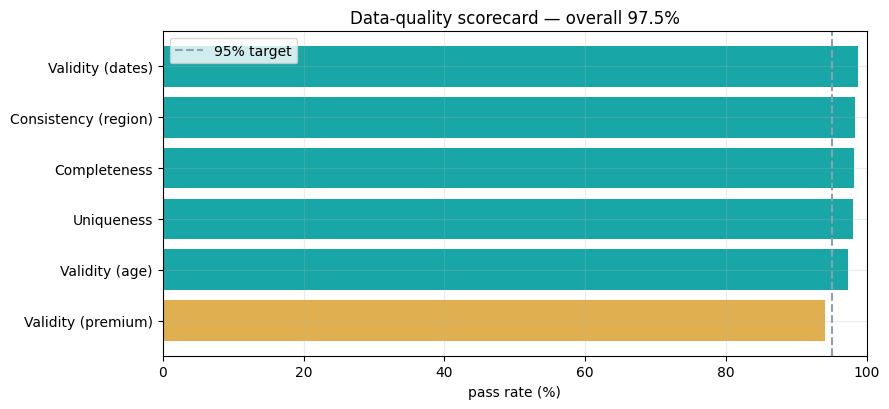

In [4]:
checks = {
    "Completeness": completeness.mean(),
    "Uniqueness": 1 - (dup_rows/len(df)),
    "Validity (age)": age_valid,
    "Validity (premium)": premium_valid,
    "Validity (dates)": date_valid,
    "Consistency (region)": region_consistent,
}
score = pd.Series(checks).sort_values()
overall = score.mean()

fig, ax = plt.subplots(figsize=(9,4.2))
colors = ["#e06666" if v<0.9 else ("#e0b050" if v<0.97 else "#18a6a6") for v in score.values]
ax.barh(score.index, score.values*100, color=colors)
ax.axvline(95, ls="--", color="#8ba0b2", label="95% target")
ax.set_xlim(0,100); ax.set_xlabel("pass rate (%)")
ax.set_title(f"Data-quality scorecard — overall {overall:.1%}"); ax.legend()
plt.tight_layout(); plt.show()


## 4. Remediation & governance
The scorecard turns "the data feels off" into specific, assignable fixes:

- **Missing premium/dates** → source validation + required-field checks at ingestion.
- **Out-of-range age** → range constraints and a maker/checker review before load.
- **Inconsistent region** (`"north "`, `"WEST"`) → standardize on a controlled vocabulary.
- **Duplicate rows** → dedupe keys and idempotent loads.

Tracked over time, this overall score becomes an **audit-ready** quality KPI — governance as a habit,
not a quarterly cleanup.

*— Aman Bohra*
